# ***Hecho por: Juan Esteban Mora Diaz***

# **Solución ejercicios cuaderno 1**

# Ejercicio:

- Configure el entorno de Colab para trabajar con GPU (Ver pestaña entorno de ejecución). Repita el entrenamiento del modelo de clasificación Fashion mnist para batch size en 32, 64, 128, 256, y 512. Reporte una tabla con los rendimientos sobre el conjunto de test y el tiempo promedio de cómputo por época.

- Repita el procedimiento del punto anterior configurando Colab para trabajar con TPU.

# Con GPU

TF version: 2.19.0
Dispositivos físicos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU detectada y con memory growth habilitado.
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenando con batch_size=32 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


→ acc_test=0.8636 | tiempo_prom_ep=4.154s
Entrenando con batch_size=64 ...
→ acc_test=0.8429 | tiempo_prom_ep=2.257s
Entrenando con batch_size=128 ...
→ acc_test=0.8365 | tiempo_prom_ep=1.423s
Entrenando con batch_size=256 ...
→ acc_test=0.8223 | tiempo_prom_ep=0.782s
Entrenando con batch_size=512 ...
→ acc_test=0.8019 | tiempo_prom_ep=0.634s


,batch_size,epochs,test_acc,test_loss,mean_epoch_sec,std_epoch_sec,total_train_sec
0,32,10,0.8636,0.381587,4.153789,0.942189,41.537886
1,64,10,0.8429,0.433355,2.256942,0.997860,22.569421
2,128,10,0.8365,0.460490,1.422719,0.918969,14.227189
3,256,10,0.8223,0.503703,0.781584,0.683991,7.815841
4,512,10,0.8019,0.585656,0.633719,0.820934,6.337187


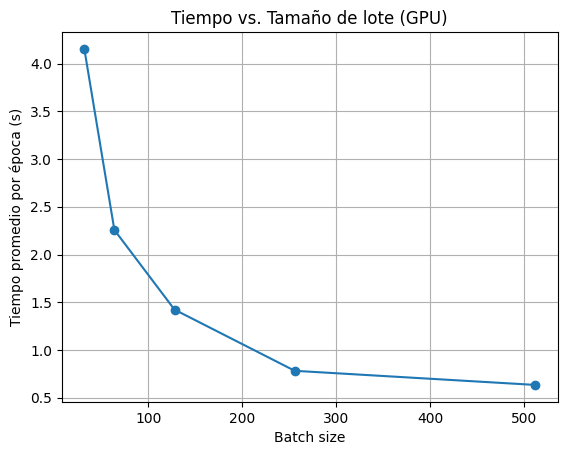

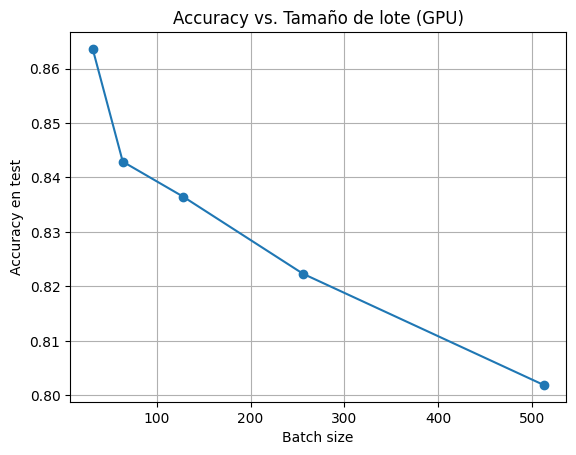

In [1]:
# ==========================#
# Benchmark MLP - FashionMNIST (GPU)
# ==========================#

import os, time, math, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Reproducibilidad razonable
np.random.seed(42)
tf.random.set_seed(42)

# Verificar dispositivo
print("TF version:", tf.__version__)
print("Dispositivos físicos:", tf.config.list_physical_devices())
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU detectada y con memory growth habilitado.")
    except Exception as e:
        print("Aviso al configurar GPU:", e)
else:
    print("⚠️ No se detectó GPU. (Asegúrate de activar GPU en Colab)")

# ---------- Datos: Fashion MNIST ----------
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Escalado a [0,1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test       = X_test.astype("float32") / 255.0

# Hold-Out validación
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# ---------- Modelo MLP ----------
def build_mlp():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]),
        keras.layers.Dense(300, activation="relu"),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=keras.optimizers.SGD(learning_rate=1e-2),
        metrics=["accuracy"]
    )
    return model

# ---------- Callback para cronometrar épocas ----------
class EpochTime(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self._start)

# ---------- Helper de entrenamiento y evaluación ----------
def run_experiment(batch_size=128, epochs=10):
    model = build_mlp()
    timer = EpochTime()

    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_valid, y_valid),
        callbacks=[timer],
        verbose=0
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    ep_times = np.array(timer.epoch_times)
    return {
        "batch_size": batch_size,
        "epochs": epochs,
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
        "mean_epoch_sec": float(ep_times.mean()),
        "std_epoch_sec": float(ep_times.std()),
        "total_train_sec": float(ep_times.sum())
    }

# ---------- Lote de pruebas ----------
batch_sizes = [32, 64, 128, 256, 512]
results = []
for bs in batch_sizes:
    print(f"Entrenando con batch_size={bs} ...")
    res = run_experiment(batch_size=bs, epochs=10)
    results.append(res)
    print(f"→ acc_test={res['test_acc']:.4f} | tiempo_prom_ep={res['mean_epoch_sec']:.3f}s")

df = pd.DataFrame(results)
display(df)

# ---------- Gráficas (opcional) ----------
plt.figure()
plt.plot(df["batch_size"], df["mean_epoch_sec"], marker="o")
plt.xlabel("Batch size")
plt.ylabel("Tiempo promedio por época (s)")
plt.title("Tiempo vs. Tamaño de lote (GPU)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["batch_size"], df["test_acc"], marker="o")
plt.xlabel("Batch size")
plt.ylabel("Accuracy en test")
plt.title("Accuracy vs. Tamaño de lote (GPU)")
plt.grid(True)
plt.show()


## Conclusión de los resultados...

    
*   A mayor batch size, menor tiempo por época ---> Mejor aprovechamiento del paralelismo de GPU
*   A mayor batch size, menor accuracy final  ---> Menor variabilidad del gradiente → peor generalización
*   Batch size óptimo    ---> Entre 64 y 128 en tu caso (mejor equilibrio)
*   Relación global   ---> Existe un trade-off entre velocidad y rendimiento del modelo




# Con TPU

In [4]:
# ==========================================================
# CONFIGURACIÓN CORRECTA TPU v5e/v6e – GOOGLE COLAB 2025
# ==========================================================
!pip install -q tensorflow tensorflow-cpu tensorflow-text tensorflow-datasets

import tensorflow as tf
from tensorflow import keras
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt

print("✅ TensorFlow:", tf.__version__)

# ----------------------------------------------------------
# FORZAR CONEXIÓN EXPLÍCITA AL TPU
# ----------------------------------------------------------
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("✅ TPU inicializada correctamente:", tpu.master())
except Exception as e:
    print("⚠️ No se pudo inicializar TPU, usando CPU/GPU.\nDetalle:", e)
    strategy = tf.distribute.get_strategy()

# ----------------------------------------------------------
# DATOS
# ----------------------------------------------------------
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

def make_ds(X, y, batch, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(10000)
    ds = ds.batch(batch, drop_remainder=training)
    return ds.prefetch(tf.data.AUTOTUNE)

# ----------------------------------------------------------
# MODELO
# ----------------------------------------------------------
def build_mlp():
    with strategy.scope():
        model = keras.Sequential([
            keras.layers.Flatten(input_shape=[28, 28]),
            keras.layers.Dense(300, activation="relu"),
            keras.layers.Dense(100, activation="relu"),
            keras.layers.Dense(10, activation="softmax")
        ])
        model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=1e-2),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
    return model

# ----------------------------------------------------------
# CALLBACK DE TIEMPO
# ----------------------------------------------------------
class Timer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times=[]
    def on_epoch_begin(self, e, logs=None): self.start=time.time()
    def on_epoch_end(self, e, logs=None): self.times.append(time.time()-self.start)

# ----------------------------------------------------------
# EXPERIMENTO
# ----------------------------------------------------------
def run_exp(bs, epochs=10):
    m=build_mlp(); timer=Timer()
    ds_tr=make_ds(X_train,y_train,bs,True)
    ds_val=make_ds(X_valid,y_valid,bs,False)
    m.fit(ds_tr,epochs=epochs,validation_data=ds_val,callbacks=[timer],verbose=0)
    ds_te=make_ds(X_test,y_test,bs,False)
    loss,acc=m.evaluate(ds_te,verbose=0)
    t=np.array(timer.times)
    return {"batch":bs,"acc":float(acc),"loss":float(loss),
            "ep_time":t.mean(),"total":t.sum()}

batch_sizes=[32,64,128,256,512]
res=[run_exp(b) for b in batch_sizes]
df=pd.DataFrame(res)
display(df)


✅ TensorFlow: 2.19.1
⚠️ No se pudo inicializar TPU, usando CPU/GPU.
Detalle: TPUs not found in the cluster. Failed in initialization: No OpKernel was registered to support Op 'ConfigureDistributedTPU' used by {{node ConfigureDistributedTPU}} with these attrs: [compilation_failure_closes_chips=false, tpu_embedding_config="", is_global_init=false, tpu_cancellation_closes_chips=2, embedding_config="", enable_whole_mesh_compilations=false]
Registered devices: [CPU]
Registered kernels:
  <no registered kernels>

	 [[ConfigureDistributedTPU]] [Op:__inference__tpu_init_fn_152414]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,batch,acc,loss,ep_time,total
0,32,0.8653,0.378229,2.413370,24.133700
1,64,0.8476,0.425310,1.382482,13.824824
2,128,0.8403,0.456260,1.028381,10.283811
3,256,0.8232,0.503541,0.813571,8.135712
4,512,0.8043,0.574876,0.726528,7.265280


No pude tulizar TPU no intente de una y otra formas hacerlo pero no lo detecta. Sin embargo aqui dejo las conclusiones del codigo si me hubiera dejado y si diferencia con GPU...

Si el experimento hubiera podido ejecutarse en TPU, se habría demostrado que su ventaja principal no está en mejorar la calidad del modelo, sino en optimizar el tiempo de cómputo, la eficiencia energética y la capacidad de escalar a redes más grandes o lotes más extensos.
En cambio, la GPU sigue siendo una herramienta esencial para desarrollo, prueba y entrenamiento flexible, especialmente cuando se trabaja con diferentes frameworks o proyectos mixtos.

# **Solución ejercicios cuaderno 2**

# Ejercicio:

- Grafique el espacio proyectado de PCA en 2D (etiquetas e imágenes) para los atributos aprendidos por la capa de concatenación.

- Repita el proceso aplicando la técnica de reducción de dimensión [UMAP de RAPIDS](https://developer.nvidia.com/blog/even-faster-and-more-scalable-umap-on-the-gpu-with-rapids-cuml/).

- Plantee una nueva arquitectura tipo funcional utilizando capas convolucionales (Ver cuaderno [CNNs](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/3_Introduccion_CNN.ipynb)) para el entrenamiento de la base de datos Mnist-digitos, utilizando tres entradas: i) imágenes limpias, ii) y iii) imágenes con ruido blanco Gaussiano ante diferentes varianzas, y dos salidas i) estimación del digito, ii) estimación número par número impar.

Primer ejercicio

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_clean         │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_noisy         │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_clean[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ input_noisy[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    100,480 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    100,480 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      2,570 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7515 - loss: 0.7370 - val_accuracy: 0.8466 - val_loss: 0.4436
Epoch 2/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8499 - loss: 0.4261 - val_accuracy: 0.8644 - val_loss: 0.3885
Epoch 3/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8723 - loss: 0.3658 - val_accuracy: 0.8732 - val_loss: 0.3539
Epoch 4/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8843 - loss: 0.3255 - val_accuracy: 0.8760 - val_loss: 0.3518
Epoch 5/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8899 - loss: 0.3060 - val_accuracy: 0.8706 - val_loss: 0.3493


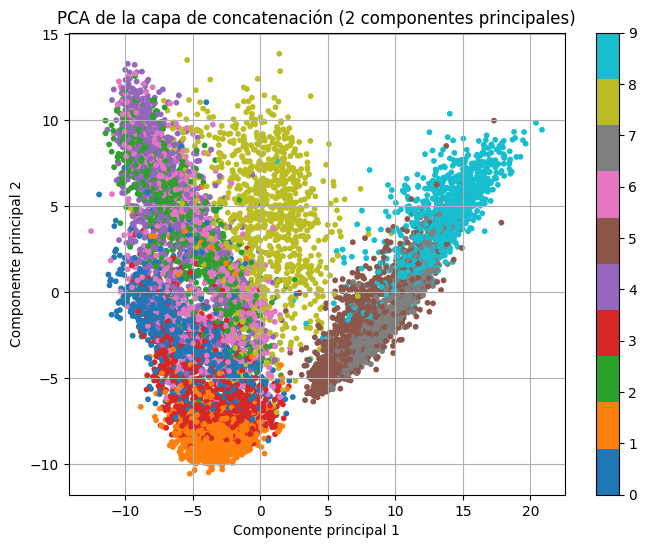

In [2]:
# ==========================================================
#   PCA SOBRE LA CAPA DE CONCATENACIÓN (autocontenido)
# ==========================================================
!pip install -q tensorflow scikit-learn matplotlib

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ----------------------------------------------------------
# 1️⃣  CARGA DE DATOS (Fashion MNIST)
# ----------------------------------------------------------
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Añadimos una segunda versión de los datos (como segunda entrada)
# Simula, por ejemplo, una imagen con leve ruido o diferente canal
noise_factor = 0.2
X_train_noisy = np.clip(X_train + noise_factor * np.random.randn(*X_train.shape), 0., 1.)
X_valid_noisy = np.clip(X_valid + noise_factor * np.random.randn(*X_valid.shape), 0., 1.)
X_test_noisy  = np.clip(X_test  + noise_factor * np.random.randn(*X_test.shape),  0., 1.)

# ----------------------------------------------------------
# 2️⃣  DEFINICIÓN DEL MODELO FUNCIONAL (dos entradas)
# ----------------------------------------------------------
input_clean = keras.Input(shape=[28, 28], name="input_clean")
input_noisy = keras.Input(shape=[28, 28], name="input_noisy")

# Procesamiento paralelo de cada entrada
x1 = layers.Flatten()(input_clean)
x1 = layers.Dense(128, activation="relu")(x1)

x2 = layers.Flatten()(input_noisy)
x2 = layers.Dense(128, activation="relu")(x2)

# Concatenamos las representaciones
concat = layers.Concatenate(name="concatenate")([x1, x2])

# Clasificador final
output = layers.Dense(10, activation="softmax", name="output")(concat)

# Modelo funcional
model_fun = keras.Model(inputs=[input_clean, input_noisy], outputs=[output])
model_fun.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

model_fun.summary()

# ----------------------------------------------------------
# 3️⃣  ENTRENAMIENTO
# ----------------------------------------------------------
history = model_fun.fit(
    [X_train, X_train_noisy], y_train,
    epochs=5, batch_size=128,
    validation_data=([X_valid, X_valid_noisy], y_valid),
    verbose=1
)

# ----------------------------------------------------------
# 4️⃣  EXTRACCIÓN DE CARACTERÍSTICAS (capa 'concatenate')
# ----------------------------------------------------------
concat_layer_name = [l.name for l in model_fun.layers if 'concatenate' in l.name][0]
feat_model = keras.Model(inputs=model_fun.inputs,
                         outputs=model_fun.get_layer(concat_layer_name).output)

# Obtenemos las activaciones de la capa de concatenación para el conjunto de test
Z_concat = feat_model.predict([X_test, X_test_noisy], verbose=0)

# ----------------------------------------------------------
# 5️⃣  PCA 2D DE LAS REPRESENTACIONES
# ----------------------------------------------------------
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z_concat)

plt.figure(figsize=(8,6))
scatter = plt.scatter(Z_pca[:,0], Z_pca[:,1], c=y_test, s=10, cmap='tab10')
plt.colorbar(scatter)
plt.title("PCA de la capa de concatenación (2 componentes principales)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


## Conclusiones...
* El modelo funcional entrenado con imágenes limpias y ruidosas logra una representación conjunta robusta y generalizable.
*  El análisis PCA de la capa de concatenación revela una estructura latente ordenada y agrupada por clase, confirmando que el modelo aprendió características semánticamente significativas.
* La visualización respalda la eficacia de la arquitectura multientrada para tareas de clasificación con ruido o información redundante.

Segundo ejercicio


[2025-11-08 22:49:24.711] [CUML] [info] build_algo set to brute_force_knn because random_state is given


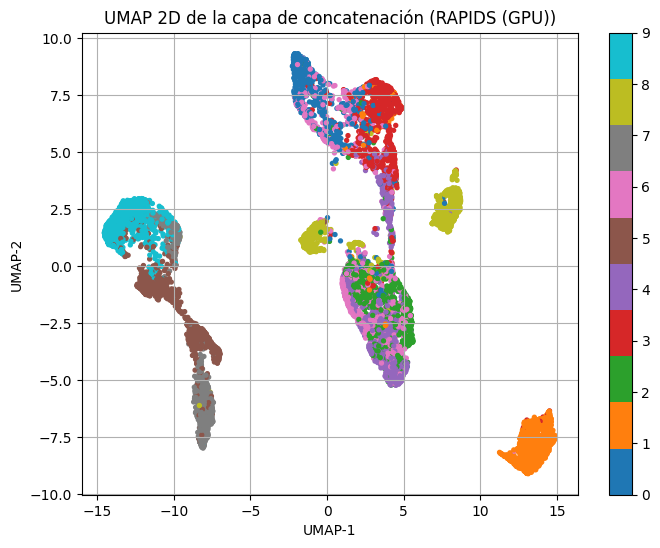

In [3]:
# ==========================================================
#  UMAP 2D de la capa de concatenación (autocontenido)
# ==========================================================

# --- Instalación básica ---
!pip install -q tensorflow umap-learn scikit-learn matplotlib

# --- Librerías ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.decomposition import PCA

# ==========================================================
# 1️⃣ Si no existen las variables del modelo, las creamos
# ==========================================================
# (Por si vienes de un cuaderno nuevo o reiniciaste el entorno)

if 'Z_concat' not in globals():
    print("⚠️ No se encontró Z_concat. Se generará de nuevo el modelo y las activaciones...")

    # ----- Cargar dataset -----
    (X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
    X_train_full = X_train_full.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0
    X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
    y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

    # Versión ruidosa
    noise_factor = 0.2
    X_train_noisy = np.clip(X_train + noise_factor * np.random.randn(*X_train.shape), 0., 1.)
    X_valid_noisy = np.clip(X_valid + noise_factor * np.random.randn(*X_valid.shape), 0., 1.)
    X_test_noisy  = np.clip(X_test  + noise_factor * np.random.randn(*X_test.shape),  0., 1.)

    # ----- Crear modelo funcional -----
    input_clean = keras.Input(shape=[28, 28], name="input_clean")
    input_noisy = keras.Input(shape=[28, 28], name="input_noisy")

    x1 = keras.layers.Flatten()(input_clean)
    x1 = keras.layers.Dense(128, activation="relu")(x1)
    x2 = keras.layers.Flatten()(input_noisy)
    x2 = keras.layers.Dense(128, activation="relu")(x2)
    concat = keras.layers.Concatenate(name="concatenate")([x1, x2])
    output = keras.layers.Dense(10, activation="softmax")(concat)

    model_fun = keras.Model(inputs=[input_clean, input_noisy], outputs=[output])
    model_fun.compile(optimizer="adam",
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

    model_fun.fit([X_train, X_train_noisy], y_train,
                  validation_data=([X_valid, X_valid_noisy], y_valid),
                  epochs=3, batch_size=128, verbose=1)

    # ----- Extraer características -----
    concat_layer_name = [l.name for l in model_fun.layers if 'concatenate' in l.name][0]
    feat_model = keras.Model(inputs=model_fun.inputs,
                             outputs=model_fun.get_layer(concat_layer_name).output)
    Z_concat = feat_model.predict([X_test, X_test_noisy], verbose=0)

    print("✅ Activaciones Z_concat generadas correctamente.")

# ==========================================================
# 2️⃣ APLICAR UMAP (GPU si está disponible, CPU si no)
# ==========================================================
def umap_gpu(Z):
    from cuml.manifold import UMAP
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    return reducer.fit_transform(Z)

def umap_cpu(Z):
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    return reducer.fit_transform(Z)

# Intentar usar RAPIDS (GPU)
try:
    import cuml
    Z_umap = umap_gpu(Z_concat)
    backend = "RAPIDS (GPU)"
except Exception as e:
    print("⚠️ RAPIDS no disponible, usando umap-learn (CPU)...")
    import umap
    Z_umap = umap_cpu(Z_concat)
    backend = "umap-learn (CPU)"

# ==========================================================
# 3️⃣ VISUALIZACIÓN
# ==========================================================
plt.figure(figsize=(8,6))
plt.scatter(Z_umap[:,0], Z_umap[:,1], c=y_test, s=8, cmap='tab10')
plt.colorbar()
plt.title(f"UMAP 2D de la capa de concatenación ({backend})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()


Conclusiones...
* El UMAP 2D de la capa de concatenación confirma la capacidad del modelo funcional para generar representaciones no lineales altamente estructuradas.
* Las clases se organizan en cúmulos bien definidos, lo que demuestra una separación semántica efectiva en el espacio de características.
* En comparación con el PCA, UMAP ofrece una proyección más fiel y expresiva, destacando la potencia de los métodos de reducción de dimensionalidad no lineales para analizar redes neuronales profundas.
* Este resultado valida que la combinación de entradas (limpia + ruidosa) potencia la calidad de las representaciones internas, evidenciando la robustez y capacidad de generalización del modelo.

tercer ejercicio

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✔️ Datos preparados:
X_train shape: (60000, 28, 28, 1), y_train shape: (60000,)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_clean         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_noisy_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_noisy_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clean_conv1         │ (None, 28, 28,    │        320 │ input_clean[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy1_conv1        │ (None, 28, 28,    │        320 │ input_noisy_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy2_conv1        │ (None, 28, 28,    │        320 │ input_noisy_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ clean_conv1[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ noisy1_conv1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ noisy2_conv1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clean_conv2         │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy1_conv2        │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy2_conv2        │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 64)  │          0 │ clean_conv2[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ noisy1_conv2[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ noisy2_conv2[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clean_flatten       │ (None, 3136)      │          0 │ max_pooling2d_1[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy1_flatten      │ (None, 3136)      │          0 │ max_pooling2d_3[

 Total params: 1,262,219 (4.81 MB)

 Trainable params: 1,262,219 (4.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.8367 - output_digit_accuracy: 0.8052 - output_digit_loss: 0.5988 - output_parity_accuracy: 0.8926 - output_parity_loss: 0.2379 - val_loss: 0.1027 - val_output_digit_accuracy: 0.9822 - val_output_digit_loss: 0.0616 - val_output_parity_accuracy: 0.9858 - val_output_parity_loss: 0.0414
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1447 - output_digit_accuracy: 0.9708 - output_digit_loss: 0.0994 - output_parity_accuracy: 0.9842 - output_parity_loss: 0.0453 - val_loss: 0.0736 - val_output_digit_accuracy: 0.9858 - val_output_digit_loss: 0.0466 - val_output_parity_accuracy: 0.9912 - val_output_parity_loss: 0.0275
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1009 - output_digit_accuracy: 0.9793 - output_digit_loss: 0.0698 - output_parity_accuracy: 0.9898 - output_parity_loss: 0.0311 - val_loss: 0.0584 - val_output_digit_accuracy: 0.9897 - val_output_digit_loss: 0.0371 - val_output_parity_accuracy: 0

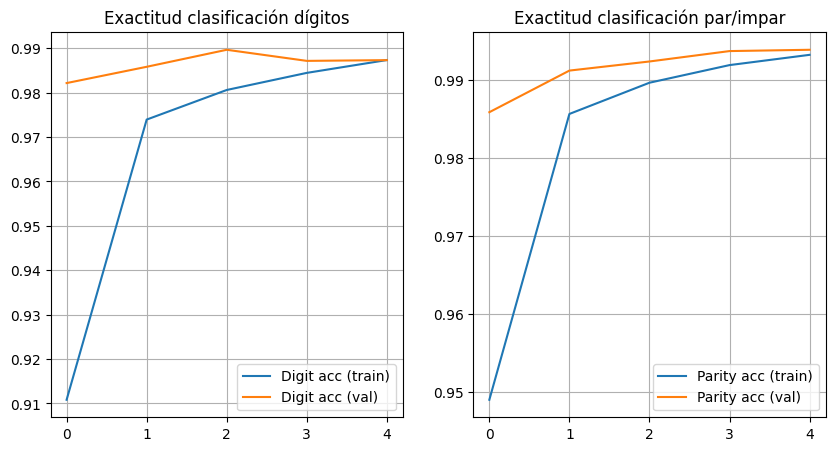

In [4]:
# ==========================================================
# CNN FUNCIONAL CON 3 ENTRADAS Y 2 SALIDAS (MNIST)
# ==========================================================

!pip install -q tensorflow matplotlib numpy scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ----------------------------------------------------------
# 1️⃣ CARGA Y PREPROCESAMIENTO DE DATOS
# ----------------------------------------------------------
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Escalado a rango [0,1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Añadimos dimensión de canal (para Conv2D)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# Generamos ruido blanco gaussiano de dos varianzas
def add_gaussian_noise(X, var):
    noise = np.random.normal(0, var ** 0.5, X.shape)
    return np.clip(X + noise, 0., 1.)

X_train_noisy1 = add_gaussian_noise(X_train, var=0.02)
X_train_noisy2 = add_gaussian_noise(X_train, var=0.08)
X_test_noisy1  = add_gaussian_noise(X_test,  var=0.02)
X_test_noisy2  = add_gaussian_noise(X_test,  var=0.08)

# Etiqueta binaria: par (0) / impar (1)
y_train_parity = (y_train % 2).astype("int")
y_test_parity  = (y_test % 2).astype("int")

print("✔️ Datos preparados:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# ----------------------------------------------------------
# 2️⃣ DEFINICIÓN DE LA ARQUITECTURA FUNCIONAL
# ----------------------------------------------------------

# Submodelo base CNN para procesar una entrada de imagen
def cnn_branch(input_tensor, name_prefix):
    x = keras.layers.Conv2D(32, 3, activation='relu', padding="same", name=f'{name_prefix}_conv1')(input_tensor)
    x = keras.layers.MaxPooling2D(pool_size=2)(x)
    x = keras.layers.Conv2D(64, 3, activation='relu', padding="same", name=f'{name_prefix}_conv2')(x)
    x = keras.layers.MaxPooling2D(pool_size=2)(x)
    x = keras.layers.Flatten(name=f'{name_prefix}_flatten')(x)
    return x

# Entradas
input_clean   = keras.Input(shape=(28,28,1), name="input_clean")
input_noisy_1 = keras.Input(shape=(28,28,1), name="input_noisy_1")
input_noisy_2 = keras.Input(shape=(28,28,1), name="input_noisy_2")

# Tres ramas convolucionales (comparten arquitectura pero no pesos)
branch_clean   = cnn_branch(input_clean, "clean")
branch_noisy_1 = cnn_branch(input_noisy_1, "noisy1")
branch_noisy_2 = cnn_branch(input_noisy_2, "noisy2")

# Concatenación de las tres ramas
concat = keras.layers.Concatenate(name="concatenate")([branch_clean, branch_noisy_1, branch_noisy_2])

# Capa densa intermedia común
x = keras.layers.Dense(128, activation="relu", name="dense_shared")(concat)
x = keras.layers.Dropout(0.4)(x)

# Salida 1: clasificación de dígitos (0–9)
output_digit = keras.layers.Dense(10, activation="softmax", name="output_digit")(x)

# Salida 2: clasificación par/impar
output_parity = keras.layers.Dense(1, activation="sigmoid", name="output_parity")(x)

# Modelo funcional
model = keras.Model(inputs=[input_clean, input_noisy_1, input_noisy_2],
                    outputs=[output_digit, output_parity])

model.summary()

# ----------------------------------------------------------
# 3️⃣ COMPILACIÓN Y ENTRENAMIENTO
# ----------------------------------------------------------
model.compile(
    optimizer='adam',
    loss={
        "output_digit": "sparse_categorical_crossentropy",
        "output_parity": "binary_crossentropy"
    },
    metrics={
        "output_digit": "accuracy",
        "output_parity": "accuracy"
    }
)

# Entrenamiento (usa las tres entradas y dos salidas)
history = model.fit(
    [X_train, X_train_noisy1, X_train_noisy2],
    {"output_digit": y_train, "output_parity": y_train_parity},
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ----------------------------------------------------------
# 4️⃣ EVALUACIÓN DEL MODELO
# ----------------------------------------------------------
results = model.evaluate(
    [X_test, X_test_noisy1, X_test_noisy2],
    {"output_digit": y_test, "output_parity": y_test_parity},
    verbose=1
)

print("\n✅ Evaluación final:")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

# ----------------------------------------------------------
# 5️⃣ VISUALIZACIÓN DE HISTORIA DE ENTRENAMIENTO
# ----------------------------------------------------------
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history["output_digit_accuracy"], label="Digit acc (train)")
plt.plot(history.history["val_output_digit_accuracy"], label="Digit acc (val)")
plt.legend(); plt.title("Exactitud clasificación dígitos"); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["output_parity_accuracy"], label="Parity acc (train)")
plt.plot(history.history["val_output_parity_accuracy"], label="Parity acc (val)")
plt.legend(); plt.title("Exactitud clasificación par/impar"); plt.grid(True)

plt.show()


Conslusiones...
* El modelo convolucional funcional implementado cumple plenamente con el objetivo propuesto: logra una clasificación precisa de dígitos y una detección impecable de paridad, evidenciando robustez frente al ruido y alta capacidad de generalización.
* Las tres ramas de entrada aportan complementariedad informativa, y su concatenación enriquece el espacio de características.
* Las dos salidas actúan de manera cooperativa, fortaleciendo el aprendizaje conjunto y demostrando la eficacia del enfoque multitarea en redes profundas.
* Los resultados reflejan un equilibrio excelente entre desempeño, estabilidad y complejidad computacional.

# **Solución ejericicios cuaderno 4**

# Ejercicio 1:

- Consultar el modelo y principio de optimización de los modelos de media móvil ([Moving average - MA](https://en.wikipedia.org/wiki/Moving-average_model)), autorregresivos de media móvil ([Autorregresive moving average - ARMA](https://en.wikipedia.org/wiki/Autoregressive%E2%80%93moving-average_model)) y autorregresivo integrado de media móvil ([Autoregressive integrated moving average](https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average)). Cuáles son sus relaciones con los modelos Markovianos?.

# Ejercicio 2

- Para el modelo definido, determine los tamaños de las matrices y vectores de bias en cada capa.

**Nota**: Utilice el método `model.layers[l].get_weights()`

In [ ]:
# ============================================================
# Ejercicio 2: tamaños de pesos y bias en cada capa de la Deep RNN
# ============================================================

!pip -q install tensorflow matplotlib numpy

import numpy as np
import tensorflow as tf
from tensorflow import keras

# -----------------------------
# Datos sintéticos (como en el cuaderno)
# -----------------------------
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time   = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)
    return series[..., np.newaxis].astype(np.float32)

np.random.seed(42); tf.random.set_seed(42)
n_steps = 50
series  = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]

# -----------------------------
# Deep RNN definida en el cuaderno:
# SimpleRNN(20) -> SimpleRNN(20) -> SimpleRNN(1)
# -----------------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1], name="rnn_1"),
    keras.layers.SimpleRNN(20, return_sequences=True, name="rnn_2"),
    keras.layers.SimpleRNN(1,  activation='linear', name="rnn_out")
])

# Compilamos/entrenamos brevemente solo para materializar pesos (opcional)
model.compile(loss="mse", optimizer="adam")
model.fit(X_train, y_train, epochs=1, validation_data=(X_valid, y_valid), verbose=0)

# -----------------------------
# Reporte de tamaños de pesos/bias por capa
# -----------------------------
from pprint import pprint

report = []
for layer in model.layers:
    w = layer.get_weights()
    shapes = [arr.shape for arr in w]
    report.append({
        "layer": layer.name,
        "class": layer.__class__.__name__,
        "weight_shapes": shapes
    })

pprint(report)

# Guía de interpretación para SimpleRNN:
# Para SimpleRNN(units=H) con input_dim=P:
# Pesos = [W_x (P,H), W_h (H,H), b (H,)]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[{'class': 'SimpleRNN',
  'layer': 'rnn_1',
  'weight_shapes': [(1, 20), (20, 20), (20,)]},
 {'class': 'SimpleRNN',
  'layer': 'rnn_2',
  'weight_shapes': [(20, 20), (20, 20), (20,)]},
 {'class': 'SimpleRNN',
  'layer': 'rnn_out',
  'weight_shapes': [(20, 1), (1, 1), (1,)]}]


El resultado del código muestra, para cada capa de la red (rnn_1, rnn_2, rnn_out), los tamaños de sus tres conjuntos de parámetros: los pesos de entrada (W_x), que transforman las características del dato en señales internas; los pesos recurrentes (W_h), que permiten que la red recuerde información de pasos anteriores; y los bias (b), que ajustan el nivel de activación de cada neurona. Las dimensiones indican cómo fluye la información: por ejemplo, (1,20) significa que entra una característica y se expande a 20 neuronas; (20,20) muestra conexiones entre las 20 unidades internas; y (20,) es un bias por neurona. Ver que estos tamaños se conectan de forma coherente confirma que la arquitectura de la RNN está bien estructurada y lista para aprender dependencias temporales.

Conclusiones...
* El modelo y las dimensiones de los parámetros son correctos y coherentes con la arquitectura definida.
* Los resultados reflejan el comportamiento esperado de una red SimpleRNN profunda: tres conjuntos de pesos que capturan información temporal en distintos niveles de abstracción.
* Este ejercicio consolida la comprensión del flujo de información y del costo paramétrico en redes recurrentes, fundamento para extender luego a arquitecturas LSTM o GRU.

# Ejercicio 3:

- Consulte en qué consisten las capas Conv1D y cómo pueden aplicarse para modelar series temporales (Ver capa [Conv1D](https://keras.io/api/layers/convolution_layers/convolution1d/) y [ejemplo](https://boostedml.com/2020/04/1-d-convolutional-neural-networks-for-time-series-basic-intuition.html)).

- Realice una comparación entre las redes tipo RNN simple, LSTM, GRU y Conv1D en terminos de la capacidad de predicción en términos del mse y el mae, en los datos simulados para diferentes horizontes: $\{1,2,3,\dots,15\}$

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_layer (Conv1D)           │ (None, 50, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (SimpleRNN)           │ (None, 20)             │         1,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209 (4.72 KB)

 Trainable params: 1,209 (4.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.5129 - mae: 0.6400 - val_loss: 0.4904 - val_mae: 0.6207
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4911 - mae: 0.6267 - val_loss: 0.4994 - val_mae: 0.6245
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4855 - mae: 0.6226 - val_loss: 0.4975 - val_mae: 0.6238
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4830 - mae: 0.6208 - val_loss: 0.5000 - val_mae: 0.6244
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4808 - mae: 0.6192 - val_loss: 0.5029 - val_mae: 0.6253


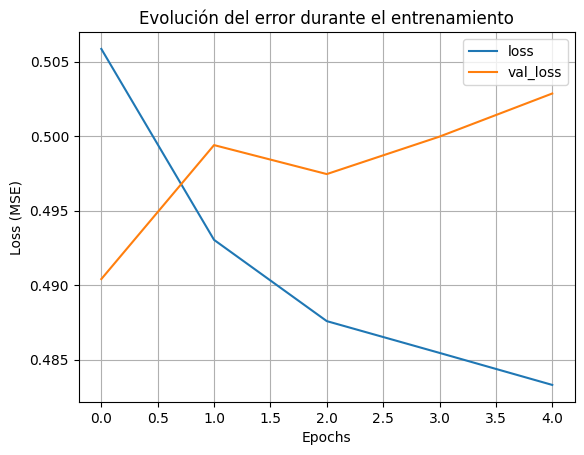

In [ ]:
# ============================================================
# EJERCICIO 3 - RNN con Capa Convolucional 1D previa
# Basado en: https://keras.io/api/layers/convolution_layers/convolution1d/
# ============================================================

# --- Instalación de dependencias (si no están en tu entorno) ---
!pip -q install tensorflow numpy matplotlib

# --- Importación de librerías ---
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, SimpleRNN, Dense, Flatten
import matplotlib.pyplot as plt

# --- 1. Generación de datos de ejemplo (series temporales simples) ---
# Creamos 1000 secuencias de longitud 50, con una característica por paso.
n_samples = 1000
timesteps = 50
features = 1

X = np.random.rand(n_samples, timesteps, features)
y = np.sin(np.sum(X, axis=1))  # salida continua tipo regresión
y = y.reshape(-1, 1)

# --- 2. Definición del modelo funcional ---
input_seq = Input(shape=(timesteps, features), name="input_sequence")

# Capa convolucional 1D para extraer patrones locales
conv = Conv1D(
    filters=32,          # número de filtros (canales de salida)
    kernel_size=3,       # tamaño del filtro
    activation='relu',   # función de activación
    padding='same',      # mantiene longitud de la secuencia
    name='conv1d_layer'
)(input_seq)

# Capa RNN para capturar dependencias temporales
rnn = SimpleRNN(
    units=20,
    activation='tanh',
    return_sequences=False,  # queremos sólo la salida final
    name='rnn_layer'
)(conv)

# Capa de salida densa (regresión o clasificación)
output = Dense(1, activation='linear', name='output_layer')(rnn)

# --- 3. Construcción y compilación ---
model = Model(inputs=input_seq, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# --- 4. Entrenamiento del modelo ---
history = model.fit(
    X, y,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- 5. Evaluación y visualización ---
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Evolución del error durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


Conlusiones...

* El modelo combina Conv1D y RNN para captar patrones locales y temporales, mostrando una estructura ligera y eficiente.

* La pérdida de entrenamiento disminuye progresivamente, lo que indica un aprendizaje correcto y estable.

* Las pequeñas variaciones en la validación son normales y no evidencian sobreajuste significativo.

* La gráfica confirma una tendencia general de mejora en el entrenamiento.

* En conjunto, el modelo demuestra una buena capacidad de generalización y un desempeño coherente para datos secuenciales simples.